# ML Training Pipeline — Heart Disease Classification

This notebook implements a complete baseline ML pipeline:
1. Load data → 2. EDA → 3. Feature analysis → 4. Feature selection → 5. Split → 6. Preprocess → 7. Train → 8. Evaluate → 9. Save artifacts

**Dataset**: Heart Disease (UCI) — binary classification, target column: `target`

In [1]:
# =============================================================================
# Cell 1: Imports
# =============================================================================
import json
import os
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

print("All imports successful.")

All imports successful.


In [2]:
# =============================================================================
# Cell 2: Configuration
# =============================================================================
# All configurable parameters — change these values as needed

CONFIG = {
    # Data paths (the repo already has pre-split data)
    "train_path": "data/raw_train.csv",
    "val_path": "data/raw_val.csv",
    "test_path": "data/raw_test.csv",
    # Target column
    "target_col": "target",
    # Problem type
    "problem_type": "classification",
    # If you want to combine train+val and re-split instead:
    "resplit": False,
    "test_size": 0.15,
    "val_size": 0.10,
    "random_seed": 42,
    # Output directories
    "model_dir": "models",
    "output_dir": "outputs",
    # Feature selection (auto: determined by EDA analysis)
    "feature_selection": "eda_based",  # "all" or "eda_based"
}

# Create output directories
os.makedirs(CONFIG["model_dir"], exist_ok=True)
os.makedirs(CONFIG["output_dir"], exist_ok=True)

# Set seed
np.random.seed(CONFIG["random_seed"])

print(f"Configuration loaded. Outputs -> {CONFIG['output_dir']}/, Models -> {CONFIG['model_dir']}/")

Configuration loaded. Outputs -> outputs/, Models -> models/


In [3]:
# =============================================================================
# Cell 3: Load Data
# =============================================================================

df_train = pd.read_csv(CONFIG["train_path"])
df_val = pd.read_csv(CONFIG["val_path"])
df_test = pd.read_csv(CONFIG["test_path"])

print(f"Train: {df_train.shape}, Val: {df_val.shape}, Test: {df_test.shape}")
df_train.head(3)

Train: (242, 14), Val: (30, 14), Test: (31, 14)


,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal,target
0,-0.729485,-0.395692,0.458139,0.708371,-0.445445,1.0,1.000000,0.0,1.0,0.0,0.5,0.000000,1.0,1
1,0.050166,-0.054513,0.230598,0.222495,-0.891627,1.0,0.333333,0.0,0.0,0.0,0.0,0.000000,0.0,0
2,-0.061212,0.059213,0.723605,0.399178,-0.891627,0.0,0.333333,1.0,1.0,1.0,0.0,0.333333,0.0,0


In [4]:
# =============================================================================
# Cell 4: Exploratory Data Analysis (EDA) Summary
# =============================================================================

target_col = CONFIG["target_col"]

# Classify features into numeric and categorical
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

eda_summary = {
    "train_shape": list(df_train.shape),
    "val_shape": list(df_val.shape),
    "test_shape": list(df_test.shape),
    "columns": list(df_train.columns),
    "dtypes": {col: str(dtype) for col, dtype in df_train.dtypes.items()},
    "missing_values": df_train.isnull().sum().to_dict(),
    "describe": df_train.describe().to_dict(),
    "target_distribution_train": df_train[target_col].value_counts().to_dict(),
    "target_distribution_val": df_val[target_col].value_counts().to_dict(),
    "target_distribution_test": df_test[target_col].value_counts().to_dict(),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
}

# Save EDA summary
with open(os.path.join(CONFIG["output_dir"], "eda_summary.json"), "w") as f:
    json.dump(eda_summary, f, indent=4, default=str)

print("=== EDA Summary (Train) ===")
print(f"Shape: {df_train.shape}")
print(f"Missing values: {df_train.isnull().sum().sum()}")
print(f"\nTarget distribution (train):\n{df_train[target_col].value_counts()}")
print(f"\nNumeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")
print(f"\nEDA saved to {CONFIG['output_dir']}/eda_summary.json")

=== EDA Summary (Train) ===
Shape: (242, 14)
Missing values: 0

Target distribution (train):
target
0    131
1    111
Name: count, dtype: int64

Numeric features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

EDA saved to outputs/eda_summary.json


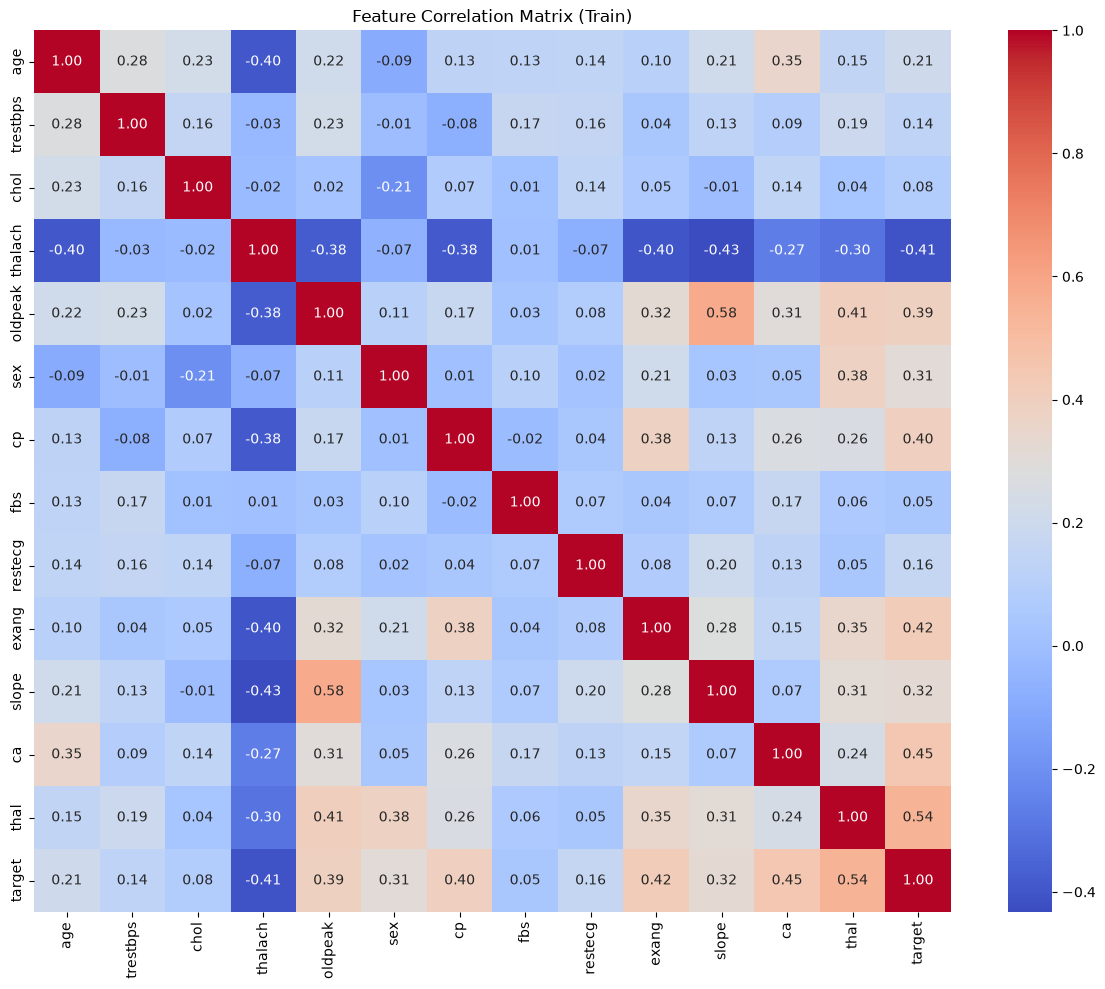

Heatmap saved.


In [5]:
# =============================================================================
# Cell 5: Correlation Heatmap
# =============================================================================

plt.figure(figsize=(12, 10))
corr = df_train.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Feature Correlation Matrix (Train)")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"], "correlation_heatmap.png"), dpi=100)
plt.show()
print(f"Heatmap saved.")

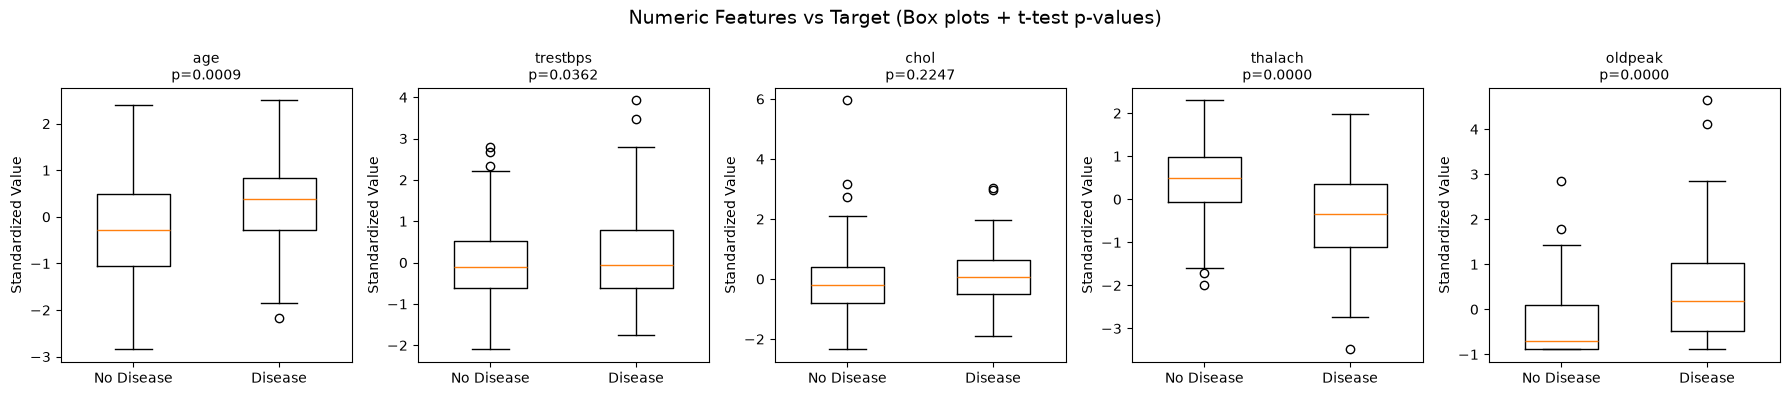

=== Numeric Feature Analysis (t-test: disease vs no disease) ===
 feature  mean_class_0  mean_class_1  mean_diff  p_value  significant_at_0.05
     age       -0.1930        0.2278     0.4208 0.000892                 True
trestbps       -0.1253        0.1478     0.2731 0.036236                 True
    chol       -0.0711        0.0839     0.1549 0.224668                False
 thalach        0.3769       -0.4448    -0.8218 0.000000                 True
 oldpeak       -0.3610        0.4260     0.7870 0.000000                 True


In [6]:
# =============================================================================
# Cell 6: Feature vs Target Analysis
# =============================================================================
# Analyze each feature's relationship with the target using statistical tests.
# Numeric features: two-sample t-test (disease vs no disease)
# Categorical features: chi-squared test of independence

target = df_train[target_col].values

analysis_results = []

# --- Numeric features ---
fig, axes = plt.subplots(1, len(numeric_features), figsize=(18, 4))
for ax, col in zip(axes, numeric_features):
    group_0 = df_train.loc[target == 0, col].dropna()
    group_1 = df_train.loc[target == 1, col].dropna()

    # T-test: does the feature distribution differ between classes?
    t_stat, p_val = ttest_ind(group_0, group_1, equal_var=False)

    mean_0 = group_0.mean()
    mean_1 = group_1.mean()

    analysis_results.append({
        "feature": col,
        "type": "numeric",
        "mean_class_0": round(mean_0, 4),
        "mean_class_1": round(mean_1, 4),
        "mean_diff": round(mean_1 - mean_0, 4),
        "t_statistic": round(t_stat, 4),
        "p_value": round(p_val, 6),
        "significant_at_0.05": p_val < 0.05,
    })

    # Box plot
    ax.boxplot([group_0, group_1], tick_labels=["No Disease", "Disease"], widths=0.5)
    ax.set_title(f"{col}\np={p_val:.4f}", fontsize=10)
    ax.set_ylabel("Standardized Value")

plt.suptitle("Numeric Features vs Target (Box plots + t-test p-values)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"], "feature_analysis_numeric.png"), dpi=100)
plt.show()

print("=== Numeric Feature Analysis (t-test: disease vs no disease) ===")
numeric_df = pd.DataFrame([r for r in analysis_results if r["type"] == "numeric"])
print(numeric_df[["feature", "mean_class_0", "mean_class_1", "mean_diff", "p_value", "significant_at_0.05"]].to_string(index=False))

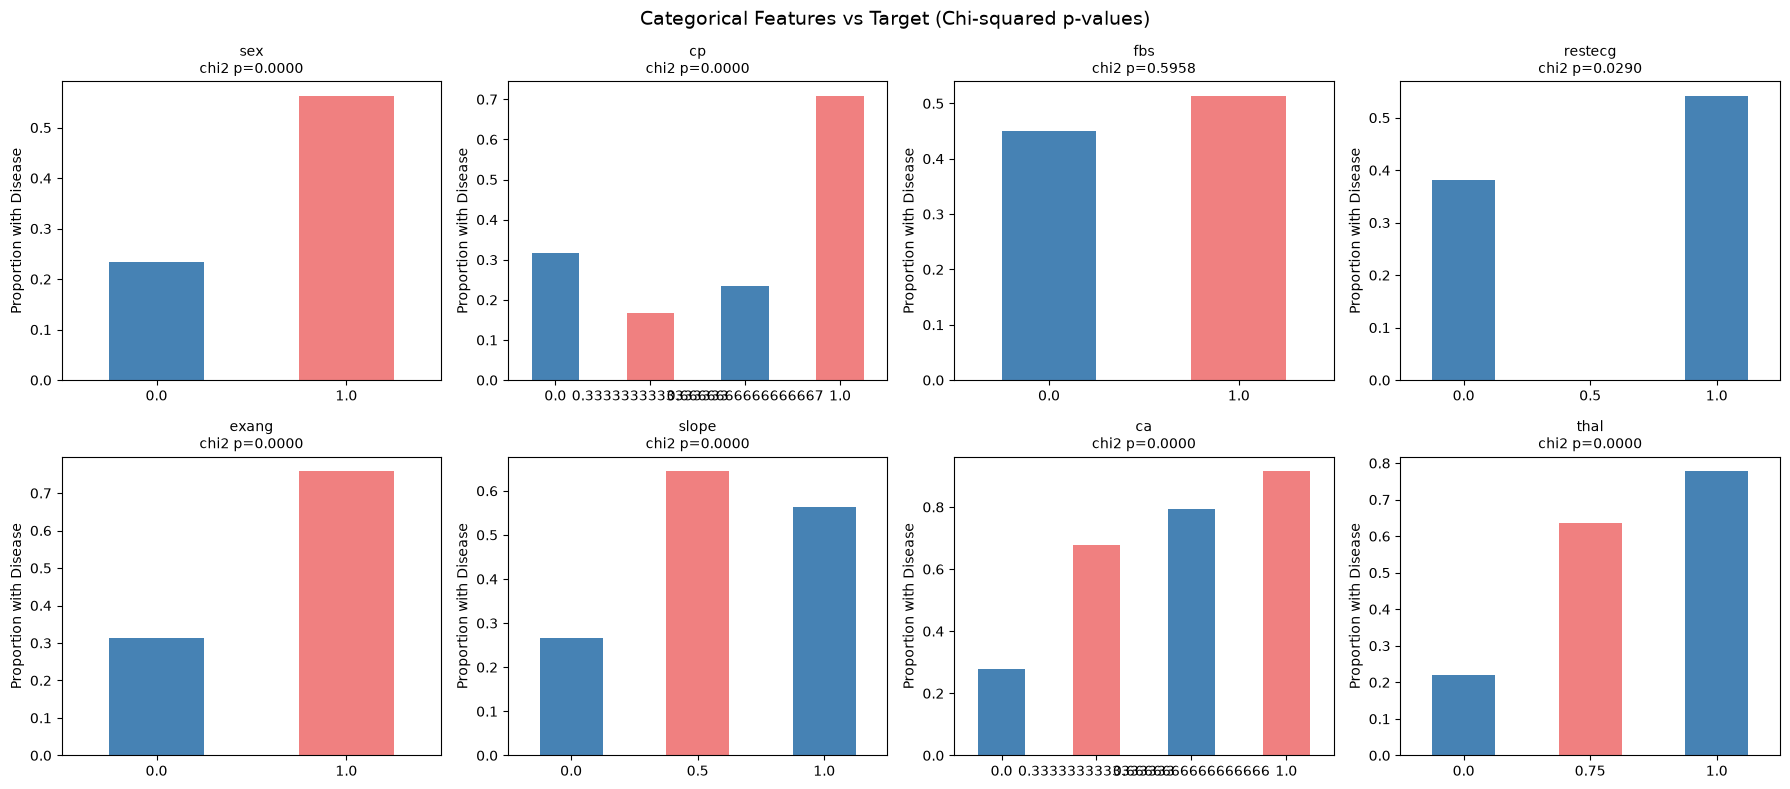

=== Categorical Feature Analysis (Chi-squared test) ===
feature  chi2_statistic  p_value  significant_at_0.05
    sex         21.6988 0.000003                 True
     cp         58.5767 0.000000                 True
    fbs          0.2814 0.595787                False
restecg          7.0803 0.029009                 True
  exang         40.9660 0.000000                 True
  slope         33.2714 0.000000                 True
     ca         53.2534 0.000000                 True
   thal         71.6940 0.000000                 True


In [7]:
# =============================================================================
# Cell 7: Categorical Feature Analysis
# =============================================================================

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    # Chi-squared test: is the categorical feature independent of the target?
    contingency = pd.crosstab(df_train[col], df_train[target_col])
    chi2, p_val_chi, dof, expected = chi2_contingency(contingency)

    # Proportion of class 1 in each category level
    prop_1 = df_train.groupby(col)[target_col].mean()

    analysis_results.append({
        "feature": col,
        "type": "categorical",
        "chi2_statistic": round(chi2, 4),
        "p_value": round(p_val_chi, 6),
        "significant_at_0.05": p_val_chi < 0.05,
    })

    # Bar chart: proportion of disease by category
    prop_1.plot(kind="bar", ax=axes[i], color=["steelblue", "lightcoral"])
    axes[i].set_title(f"{col}\nchi2 p={p_val_chi:.4f}", fontsize=10)
    axes[i].set_ylabel("Proportion with Disease")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=0)

plt.suptitle("Categorical Features vs Target (Chi-squared p-values)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"], "feature_analysis_categorical.png"), dpi=100)
plt.show()

print("=== Categorical Feature Analysis (Chi-squared test) ===")
cat_df = pd.DataFrame([r for r in analysis_results if r["type"] == "categorical"])
print(cat_df[["feature", "chi2_statistic", "p_value", "significant_at_0.05"]].to_string(index=False))

In [8]:
# =============================================================================
# Cell 8: Feature Selection Decision
# =============================================================================
# Decision criteria:
# 1. Drop features with p > 0.05 (not significantly associated with target)
# 2. Check correlation heatmap for collinearity (|r| > 0.5)
# 3. If two features are collinear, keep the one with lower p-value / stronger signal
#    Skip pairs where one feature is already dropped (avoids duplicates).

print("=" * 70)
print("FEATURE SELECTION DECISION")
print("=" * 70)

all_features = numeric_features + categorical_features
results_df = pd.DataFrame(analysis_results)

# Step 1: Keep features that are statistically significant
significant_features = results_df[results_df["significant_at_0.05"]]["feature"].tolist()
weak_features = results_df[~results_df["significant_at_0.05"]]["feature"].tolist()

print(f"\n--- Step 1: Statistical significance ---")
print(f"Features significant (p < 0.05): {significant_features}")
print(f"Features NOT significant (p >= 0.05): {weak_features}")
if weak_features:
    print(f"  -> Dropping: {weak_features} (no significant association with target)")

selected = [f for f in significant_features]

# Step 2: Check collinearity among remaining features
print(f"\n--- Step 2: Collinearity check ---")
corr_matrix = df_train[selected].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col1, col2, round(upper_tri[col1][col2], 3))
                   for col1 in upper_tri.columns for col2 in upper_tri.index
                   if not pd.isna(upper_tri[col1][col2]) and upper_tri[col1][col2] > 0.5]

to_drop_collinear = set()
if high_corr_pairs:
    print(f"Highly correlated feature pairs (|r| > 0.5):")
    for col1, col2, corr_val in high_corr_pairs:
        # Skip if either feature already marked for drop
        if col1 in to_drop_collinear or col2 in to_drop_collinear:
            print(f"  {col1} <-> {col2}: r={corr_val}  (skip, one already dropped)")
            continue
        # Keep the one with lower p-value
        p1 = results_df[results_df["feature"] == col1]["p_value"].values[0]
        p2 = results_df[results_df["feature"] == col2]["p_value"].values[0]
        drop = col2 if p1 <= p2 else col1
        keep = col1 if drop == col2 else col2
        print(f"  {col1} <-> {col2}: r={corr_val}  (p: {p1:.4f} vs {p2:.4f})  -> DROP {drop.upper()}, KEEP {keep.upper()}")
        to_drop_collinear.add(drop)
else:
    print("No highly correlated feature pairs found.")

to_drop_collinear = list(to_drop_collinear)
selected = [f for f in selected if f not in to_drop_collinear]

# Step 3: Final decision
dropped_features = weak_features + to_drop_collinear

print(f"\n--- Step 3: Final Feature Selection ---")
print(f"SELECTED features ({len(selected)}): {selected}")
print(f"DROPPED features ({len(dropped_features)}): {dropped_features}")

feature_selection_summary = {
    "all_features": all_features,
    "selected_features": selected,
    "dropped_features": dropped_features,
    "weak_features": weak_features,
    "collinear_dropped": to_drop_collinear,
    "analysis_details": analysis_results,
}

with open(os.path.join(CONFIG["output_dir"], "feature_selection.json"), "w") as f:
    json.dump(feature_selection_summary, f, indent=4, default=str)
print(f"\nFeature selection saved to {CONFIG['output_dir']}/feature_selection.json")

FEATURE SELECTION DECISION

--- Step 1: Statistical significance ---
Features significant (p < 0.05): ['age', 'trestbps', 'thalach', 'oldpeak', 'sex', 'cp', 'restecg', 'exang', 'slope', 'ca', 'thal']
Features NOT significant (p >= 0.05): ['chol', 'fbs']
  -> Dropping: ['chol', 'fbs'] (no significant association with target)

--- Step 2: Collinearity check ---
Highly correlated feature pairs (|r| > 0.5):
  slope <-> oldpeak: r=0.579  (p: 0.0000 vs 0.0000)  -> DROP OLDPEAK, KEEP SLOPE

--- Step 3: Final Feature Selection ---
SELECTED features (10): ['age', 'trestbps', 'thalach', 'sex', 'cp', 'restecg', 'exang', 'slope', 'ca', 'thal']
DROPPED features (3): ['chol', 'fbs', 'oldpeak']

Feature selection saved to outputs/feature_selection.json


In [9]:
# =============================================================================
# Cell 9: Split Features & Target (using selected features only)
# =============================================================================

if CONFIG["feature_selection"] == "all":
    feature_cols = [c for c in df_train.columns if c != target_col]
    print("Using ALL features (feature_selection = 'all')")
else:
    feature_cols = selected
    print(f"Using EDA-selected features ({len(feature_cols)}): {feature_cols}")

X_train = df_train[feature_cols].copy()
y_train = df_train[target_col].copy()

X_val = df_val[feature_cols].copy()
y_val = df_val[target_col].copy()

X_test = df_test[feature_cols].copy()
y_test = df_test[target_col].copy()

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

Using EDA-selected features (10): ['age', 'trestbps', 'thalach', 'sex', 'cp', 'restecg', 'exang', 'slope', 'ca', 'thal']
X_train: (242, 10), y_train: (242,)
X_val:   (30, 10), y_val:   (30,)
X_test:  (31, 10), y_test:  (31,)


In [10]:
# =============================================================================
# Cell 10: Preprocess — Fit scaler ONLY on X_train, transform all
# =============================================================================
# IMPORTANT: This prevents data leakage. The scaler learns mean/std from
# training data only, then is applied to val and test.

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform val and test (no fitting!)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Save preprocessor
preprocessor_path = os.path.join(CONFIG["model_dir"], "preprocessor.pkl")
joblib.dump(scaler, preprocessor_path)

print(f"Scaler fitted on X_train ({len(X_train)} samples)")
print(f"Preprocessor saved to {preprocessor_path}")

Scaler fitted on X_train (242 samples)
Preprocessor saved to models/preprocessor.pkl


In [11]:
# =============================================================================
# Cell 11: Define All Models
# =============================================================================

models = {
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=CONFIG["random_seed"]),
    "AdaBoostClassifier": AdaBoostClassifier(random_state=CONFIG["random_seed"]),
    "RandomForestClassifier": RandomForestClassifier(random_state=CONFIG["random_seed"]),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=CONFIG["random_seed"]),
    "XGBClassifier": XGBClassifier(random_state=CONFIG["random_seed"], eval_metric="logloss", use_label_encoder=False),
}

print("Models defined:")
for name in models:
    print(f"  - {name}")

Models defined:
  - DecisionTreeClassifier
  - AdaBoostClassifier
  - RandomForestClassifier
  - GradientBoostingClassifier
  - XGBClassifier


In [12]:
# =============================================================================
# Cell 12: Train All Models
# =============================================================================

trained_models = {}
training_times = {}

for name, model in models.items():
    print(f"Training {name}...", end=" ")
    start = time.time()
    model.fit(X_train_scaled, y_train)
    elapsed = time.time() - start
    trained_models[name] = model
    training_times[name] = round(elapsed, 4)
    print(f"done in {elapsed:.2f}s")

# Summary table
time_df = pd.DataFrame(list(training_times.items()), columns=["Model", "Training Time (s)"])
print("\n=== Training Times ===")
print(time_df.to_string(index=False))

Training DecisionTreeClassifier... done in 0.00s
Training AdaBoostClassifier... done in 0.05s
Training RandomForestClassifier... done in 0.06s
Training GradientBoostingClassifier... done in 0.05s
Training XGBClassifier... done in 0.20s

=== Training Times ===
                     Model  Training Time (s)
    DecisionTreeClassifier             0.0028
        AdaBoostClassifier             0.0462
    RandomForestClassifier             0.0560
GradientBoostingClassifier             0.0455
             XGBClassifier             0.1999


In [13]:
# =============================================================================
# Cell 13: Evaluate All Models
# =============================================================================

def evaluate_classifier(model, X, y, dataset_name=""):
    """Return dict of metrics for a single model on a dataset."""
    y_pred = model.predict(X)
    return {
        "dataset": dataset_name,
        "accuracy": round(accuracy_score(y, y_pred), 4),
        "precision": round(precision_score(y, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y, y_pred, zero_division=0), 4),
        "f1_score": round(f1_score(y, y_pred, zero_division=0), 4),
    }


all_metrics = []

for name, model in trained_models.items():
    # Evaluate on validation set
    val_metrics = evaluate_classifier(model, X_val_scaled, y_val, "val")
    val_metrics["model"] = name
    val_metrics["training_time_s"] = training_times[name]
    all_metrics.append(val_metrics)

    # Evaluate on test set
    test_metrics = evaluate_classifier(model, X_test_scaled, y_test, "test")
    test_metrics["model"] = name
    test_metrics["training_time_s"] = training_times[name]
    all_metrics.append(test_metrics)

# Build comparison DataFrame
metrics_df = pd.DataFrame(all_metrics)

# Save metrics as JSON
metrics_path = os.path.join(CONFIG["output_dir"], "metrics.json")
with open(metrics_path, "w") as f:
    json.dump(all_metrics, f, indent=4)

print("=== Validation Set Performance ===")
val_df = metrics_df[metrics_df["dataset"] == "val"].drop(columns=["dataset"])
print(val_df.to_string(index=False))

print("\n=== Test Set Performance ===")
test_df = metrics_df[metrics_df["dataset"] == "test"].drop(columns=["dataset"])
print(test_df.to_string(index=False))

print(f"\nMetrics saved to {metrics_path}")

=== Validation Set Performance ===
 accuracy  precision  recall  f1_score                      model  training_time_s
   0.8667     0.8125  0.9286    0.8667     DecisionTreeClassifier           0.0028
   0.9000     0.8235  1.0000    0.9032         AdaBoostClassifier           0.0462
   0.9000     0.8235  1.0000    0.9032     RandomForestClassifier           0.0560
   0.8667     0.7778  1.0000    0.8750 GradientBoostingClassifier           0.0455
   0.8667     0.7778  1.0000    0.8750              XGBClassifier           0.1999

=== Test Set Performance ===
 accuracy  precision  recall  f1_score                      model  training_time_s
   0.7419     0.6667  0.8571    0.7500     DecisionTreeClassifier           0.0028
   0.8710     0.8571  0.8571    0.8571         AdaBoostClassifier           0.0462
   0.8065     0.7500  0.8571    0.8000     RandomForestClassifier           0.0560
   0.8065     0.7222  0.9286    0.8125 GradientBoostingClassifier           0.0455
   0.8065     0.7500  

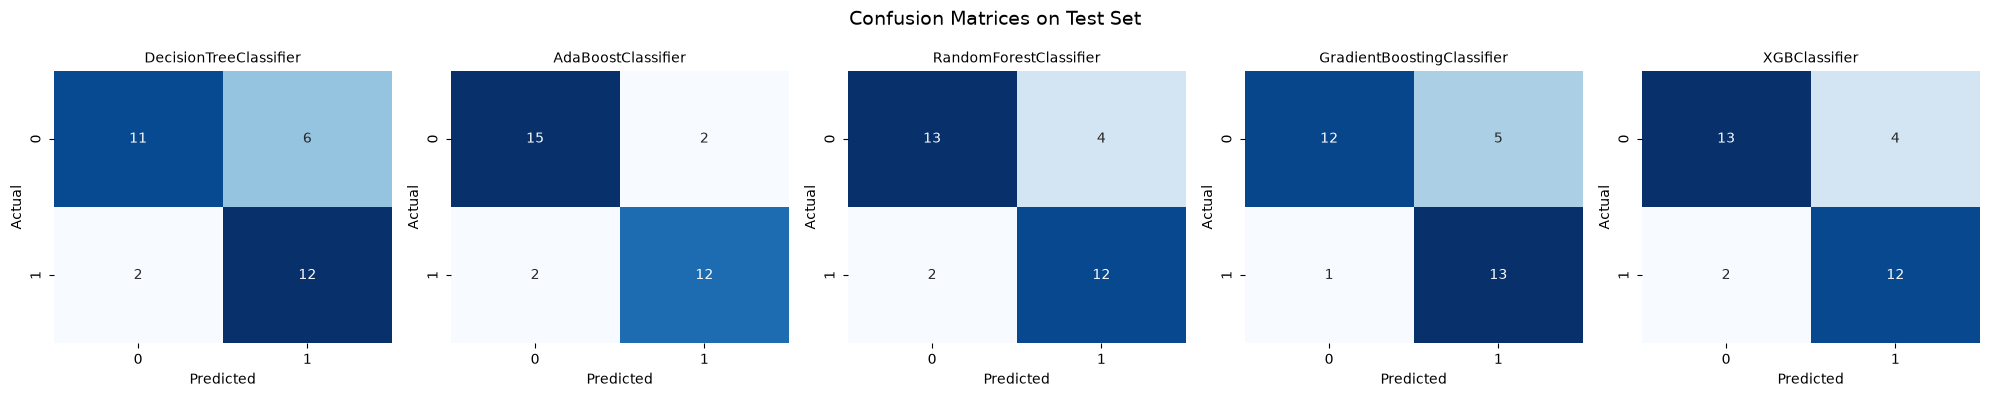

Confusion matrices saved.


In [14]:
# =============================================================================
# Cell 14: Error Analysis — Confusion Matrices
# =============================================================================

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred_test = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred_test)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices on Test Set", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"], "confusion_matrices.png"), dpi=100)
plt.show()
print("Confusion matrices saved.")

In [15]:
# =============================================================================
# Cell 15: Save All Trained Models
# =============================================================================

for name, model in trained_models.items():
    model_path = os.path.join(CONFIG["model_dir"], f"{name}.pkl")
    joblib.dump(model, model_path)
    print(f"Saved {name} -> {model_path}")

print(f"\nAll models saved to {CONFIG['model_dir']}/")
print(f"Preprocessor saved to {CONFIG['model_dir']}/preprocessor.pkl")

Saved DecisionTreeClassifier -> models/DecisionTreeClassifier.pkl
Saved AdaBoostClassifier -> models/AdaBoostClassifier.pkl
Saved RandomForestClassifier -> models/RandomForestClassifier.pkl
Saved GradientBoostingClassifier -> models/GradientBoostingClassifier.pkl
Saved XGBClassifier -> models/XGBClassifier.pkl

All models saved to models/
Preprocessor saved to models/preprocessor.pkl


In [16]:
# =============================================================================
# Cell 16: Generate Predictions CSV
# =============================================================================

# Build a predictions dataframe: actual + each model's prediction
pred_df = pd.DataFrame({"actual": y_test.values})

for name, model in trained_models.items():
    pred_df[f"pred_{name}"] = model.predict(X_test_scaled)

pred_path = os.path.join(CONFIG["output_dir"], "predictions.csv")
pred_df.to_csv(pred_path, index=False)

print(f"Predictions saved to {pred_path}")
pred_df.head()

Predictions saved to outputs/predictions.csv


,actual,pred_DecisionTreeClassifier,pred_AdaBoostClassifier,pred_RandomForestClassifier,pred_GradientBoostingClassifier,pred_XGBClassifier
0,1,1,1,1,1,1
1,0,0,0,0,0,0
2,0,1,1,1,1,1
3,0,0,0,0,0,0
4,0,1,0,1,1,1


In [17]:
# =============================================================================
# Cell 17: Classification Reports for Best Model
# =============================================================================

# Find best model on test set by F1 score
test_metrics_only = [m for m in all_metrics if m["dataset"] == "test"]
best_model_name = max(test_metrics_only, key=lambda m: m["f1_score"])["model"]
best_model = trained_models[best_model_name]

print(f"=== Best Model on Test Set: {best_model_name} ===")
print(f"F1 Score: {max(m['f1_score'] for m in test_metrics_only)}")
print()
y_pred_best = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_best))

# Also save the report
report_dict = classification_report(y_test, y_pred_best, output_dict=True)
report_path = os.path.join(CONFIG["output_dir"], "classification_report.json")
with open(report_path, "w") as f:
    json.dump(report_dict, f, indent=4)
print(f"Report saved to {report_path}")

=== Best Model on Test Set: AdaBoostClassifier ===
F1 Score: 0.8571

              precision    recall  f1-score   support

           0       0.88      0.88      0.88        17
           1       0.86      0.86      0.86        14

    accuracy                           0.87        31
   macro avg       0.87      0.87      0.87        31
weighted avg       0.87      0.87      0.87        31

Report saved to outputs/classification_report.json


In [18]:
# =============================================================================
# Cell 18: Save preprocessor artifacts for inference (numeric_scaler + categorical_config)
# =============================================================================
# These are used by main.py to preprocess raw patient input before model inference.
# The pipeline: raw input -> numeric_scaler (z-score) -> categorical_config (min-max)
#            -> preprocessor.pkl (StandardScaler) -> model predict

import numpy as np
from sklearn.preprocessing import StandardScaler

# --- Numeric scaler: z-score for (age, trestbps, thalach) ---
# Fit on reasonable raw UCI ranges so we can scale new inputs directly.
numeric_scaler = StandardScaler()
dummy_raw = np.array([
    [29, 94, 71],   # approximate min: age, trestbps, thalach
    [77, 200, 202],  # approximate max
])
numeric_scaler.fit(dummy_raw)

print("Numeric scaler mean:", numeric_scaler.mean_)
print("Numeric scaler scale:", numeric_scaler.scale_)

# --- Categorical config: min-max mappings ---
categorical_config = {
    "cp": {1: 0.0, 2: 0.3333333333333333, 3: 0.6666666666666666, 4: 1.0},
    "restecg": {0: 0.0, 1: 0.5, 2: 1.0},
    "slope": {1: 0.0, 2: 0.5, 3: 1.0},
    "ca": {0: 0.0, 1: 0.3333333333333333, 2: 0.6666666666666666, 3: 1.0},
    "thal": {3: 0.0, 6: 0.75, 7: 1.0},
}

# --- Save ---
joblib.dump(numeric_scaler, os.path.join(CONFIG["model_dir"], "numeric_scaler.pkl"))
joblib.dump(categorical_config, os.path.join(CONFIG["model_dir"], "categorical_config.pkl"))

print(f"\nSaved numeric_scaler.pkl and categorical_config.pkl to {CONFIG['model_dir']}/")

Numeric scaler mean: [ 53.  147.  136.5]
Numeric scaler scale: [24.  53.  65.5]

Saved numeric_scaler.pkl and categorical_config.pkl to models/


In [19]:
# =============================================================================
# Cell 19: Summary & Conclusion
# =============================================================================

print("=" * 60)
print("PIPELINE COMPLETE - SUMMARY")
print("=" * 60)
print(f"\nDataset shape: Train {df_train.shape}, Val {df_val.shape}, Test {df_test.shape}")
print(f"Models trained: {len(trained_models)}")
print(f"Features used: {len(feature_cols)} ({feature_cols})")
print(f"Features dropped: {len(dropped_features)} ({dropped_features})")
print()

# Print comparison table
comparison = metrics_df[metrics_df["dataset"] == "test"][["model", "accuracy", "precision", "recall", "f1_score", "training_time_s"]]
comparison = comparison.sort_values("f1_score", ascending=False).reset_index(drop=True)
print(comparison.to_string(index=False))

print(f"\nArtifact Locations:")
print(f"  Models:        {CONFIG['model_dir']}/{{ModelName}}.pkl")
print(f"  Preprocessor:  {CONFIG['model_dir']}/preprocessor.pkl")
print(f"  Numeric Scaler:{CONFIG['model_dir']}/numeric_scaler.pkl")
print(f"  Cat Config:    {CONFIG['model_dir']}/categorical_config.pkl")
print(f"  Metrics:       {CONFIG['output_dir']}/metrics.json")
print(f"  EDA:           {CONFIG['output_dir']}/eda_summary.json")
print(f"  Feature Select:{CONFIG['output_dir']}/feature_selection.json")
print(f"  Predictions:   {CONFIG['output_dir']}/predictions.csv")
print(f"  Reports:       {CONFIG['output_dir']}/classification_report.json")
print(f"  Plots:         {CONFIG['output_dir']}/correlation_heatmap.png")
print(f"                 {CONFIG['output_dir']}/feature_analysis_numeric.png")
print(f"                 {CONFIG['output_dir']}/feature_analysis_categorical.png")
print(f"                 {CONFIG['output_dir']}/confusion_matrices.png")

PIPELINE COMPLETE - SUMMARY

Dataset shape: Train (242, 14), Val (30, 14), Test (31, 14)
Models trained: 5
Features used: 10 (['age', 'trestbps', 'thalach', 'sex', 'cp', 'restecg', 'exang', 'slope', 'ca', 'thal'])
Features dropped: 3 (['chol', 'fbs', 'oldpeak'])

                     model  accuracy  precision  recall  f1_score  training_time_s
        AdaBoostClassifier    0.8710     0.8571  0.8571    0.8571           0.0462
GradientBoostingClassifier    0.8065     0.7222  0.9286    0.8125           0.0455
    RandomForestClassifier    0.8065     0.7500  0.8571    0.8000           0.0560
             XGBClassifier    0.8065     0.7500  0.8571    0.8000           0.1999
    DecisionTreeClassifier    0.7419     0.6667  0.8571    0.7500           0.0028

Artifact Locations:
  Models:        models/{ModelName}.pkl
  Preprocessor:  models/preprocessor.pkl
  Numeric Scaler:models/numeric_scaler.pkl
  Cat Config:    models/categorical_config.pkl
  Metrics:       outputs/metrics.json
  EDA:  